# Production fit speedup

- Compare matched full-spectrum fits with total photometry.

In [1]:
from pathlib import Path
import json
import sys
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
from scipy.special import softmax

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from validate_ceridwen_speedups import comparison, RESULT_ROOT, TARGETS, SEEDS
report = comparison()
rows = []
for pair in report["pairs"]:
    rows.append({
        "target": pair["target"], "seed": pair["seed"],
        "baseline fit / s": pair["timing"]["baseline"]["total_fit_seconds"],
        "optimized fit / s": pair["timing"]["reduce"]["total_fit_seconds"],
        "fit speedup": pair["total_fit_speedup"],
        "sampling speedup": pair["sampling_speedup"],
        "evidence shift / combined error": pair["evidence"]["delta_over_combined_error"],
    })
table = pd.DataFrame(rows)
display(table.round(4))
display({k: report[k] for k in ("gpu", "grid_schema", "precision", "metric", "median_total_fit_speedup", "median_sampling_speedup", "performance_gate_passed")})


,target,seed,baseline fit / s,optimized fit / s,fit speedup,sampling speedup,evidence shift / combined error
0,M1_210210,20260906,566.3935,479.1911,1.1820,1.1816,0.0
1,M1_210210,20260907,536.8009,454.4334,1.1813,1.1815,0.0
2,M5_172669,20260906,536.5002,454.1508,1.1813,1.1815,0.0
3,M5_172669,20260907,540.9379,458.1692,1.1807,1.1809,0.0


{'gpu': 'NVIDIA GeForce RTX 5060',
 'grid_schema': '2.1',
 'precision': 'JAX x64 enabled; existing float32 CSP grid and spectrum assembly preserved',
 'metric': 'data loading through completed HDF5 save; plotting excluded',
 'median_total_fit_speedup': 1.1812896131244675,
 'median_sampling_speedup': 1.1814947227336605,
 'performance_gate_passed': True}

- Include loading, compilation, sampling, and HDF5 saving.

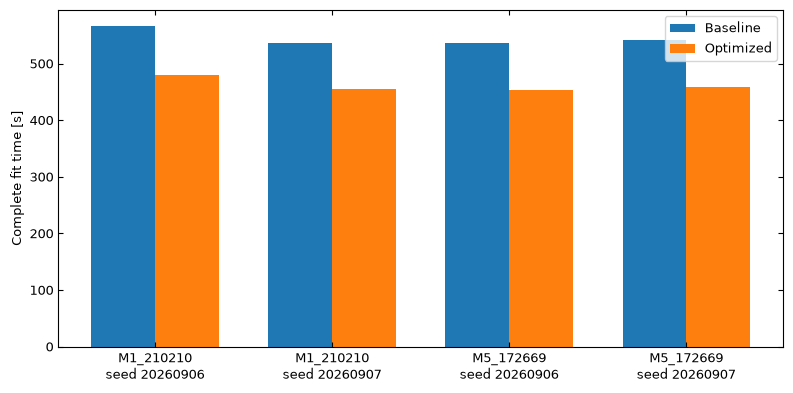

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(table))
ax.bar(x-.18, table["baseline fit / s"], .36, label="Baseline")
ax.bar(x+.18, table["optimized fit / s"], .36, label="Optimized")
ax.set_xticks(x, [f"{r.target}\nseed {r.seed}" for r in table.itertuples()])
ax.set_ylabel("Complete fit time [s]")
ax.legend()
fig.tight_layout()
plt.show()


- Compare posterior medians against their credible interval widths.

In [3]:
agreement=[]
for pair in report["pairs"]:
    for kind in ("parameters", "derived"):
        for name, values in pair[kind].items():
            agreement.append({"target": pair["target"], "seed": pair["seed"], "kind": kind,
                              "parameter": name, "median shift / 68% half-width": values["median_shift_over_68pct_half_width"]})
agreement=pd.DataFrame(agreement)
display(agreement.groupby(["target", "kind"])["median shift / 68% half-width"].max().to_frame())
display(agreement.sort_values("median shift / 68% half-width", ascending=False).head(12))


median shift / 68% half-width
target    kind                                     
M1_210210 derived                      1.273632e-11
          parameters                   1.990625e-10
M5_172669 derived                      1.250984e-12
          parameters                   4.449716e-13

,target,seed,kind,parameter,median shift / 68% half-width
39,M1_210210,20260907,parameters,logsfr_ratios[5],1.990625e-10
38,M1_210210,20260907,parameters,logsfr_ratios[4],1.095056e-10
43,M1_210210,20260907,parameters,spectrum_scaling,7.661775e-11
34,M1_210210,20260907,parameters,logsfr_ratios[0],7.079466e-11
41,M1_210210,20260907,parameters,logmass,6.662393e-11
36,M1_210210,20260907,parameters,logsfr_ratios[2],3.801169e-11
35,M1_210210,20260907,parameters,logsfr_ratios[1],1.353789e-11
59,M1_210210,20260907,derived,calibration a_2,1.273632e-11
31,M1_210210,20260907,parameters,Z,1.119749e-11
40,M1_210210,20260907,parameters,logsfr_ratios[6],7.579002e-12


- Compare the saved SFH and mass-weighted age distributions.

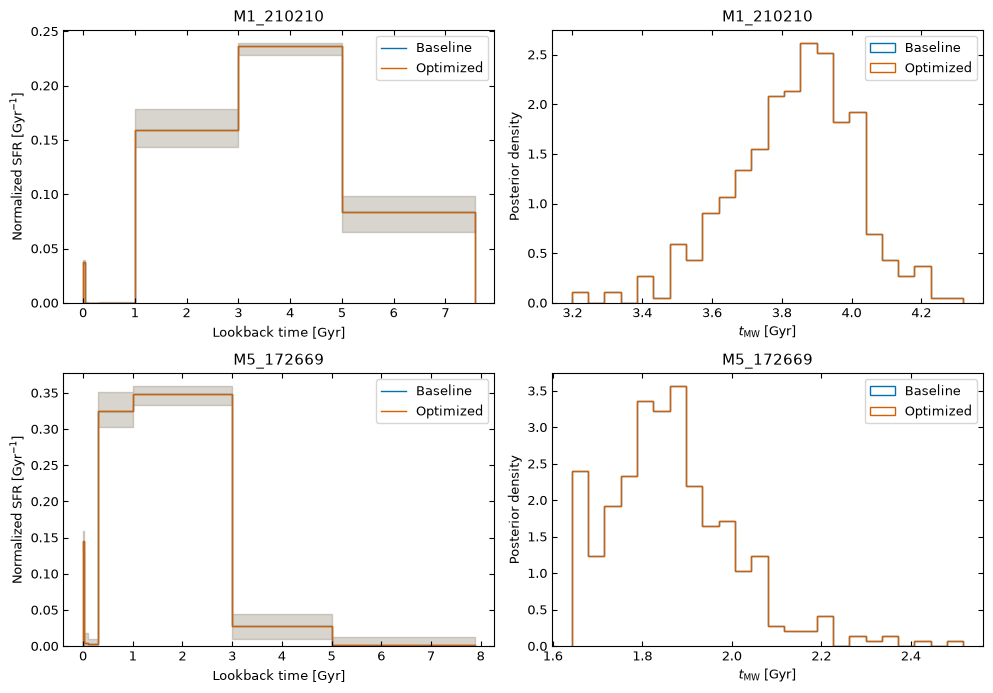

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for row, target in enumerate(TARGETS):
    for variant, label, color in (("baseline", "Baseline", "#0072B2"), ("reduce", "Optimized", "#D55E00")):
        folder=RESULT_ROOT/f"{target}-{SEEDS[0]}-{variant}"
        with h5py.File(folder/"ceridwen_derived_outputs.h5") as f:
            t=f["sfh/lookback_time_gyr"][()]
            draws=f["sfh/normalized_sfr_draws"][()]
            bin_sfr=.5*(draws[:,:-1]+draws[:,1:])*1e9
            q=np.quantile(bin_sfr,[.16,.5,.84],axis=0)
            axes[row,0].stairs(q[1],t,color=color,label=label)
            axes[row,0].fill_between(t,np.r_[q[0],q[0,-1]],np.r_[q[2],q[2,-1]],
                                     step="post",color=color,alpha=.15)
            axes[row,1].hist(f["sfh/mass_weighted_age_gyr"][()],bins=24,density=True,
                             histtype="step",color=color,label=label)
    axes[row,0].set(xlabel="Lookback time [Gyr]",ylabel=r"Normalized SFR [$\mathrm{Gyr}^{-1}$]",title=target)
    axes[row,1].set(xlabel=r"$t_\mathrm{MW}$ [Gyr]",ylabel="Posterior density",title=target)
    axes[row,0].legend();axes[row,1].legend()
fig.tight_layout()
plt.show()


- Retain masked gaps in the posterior spectrum comparison.

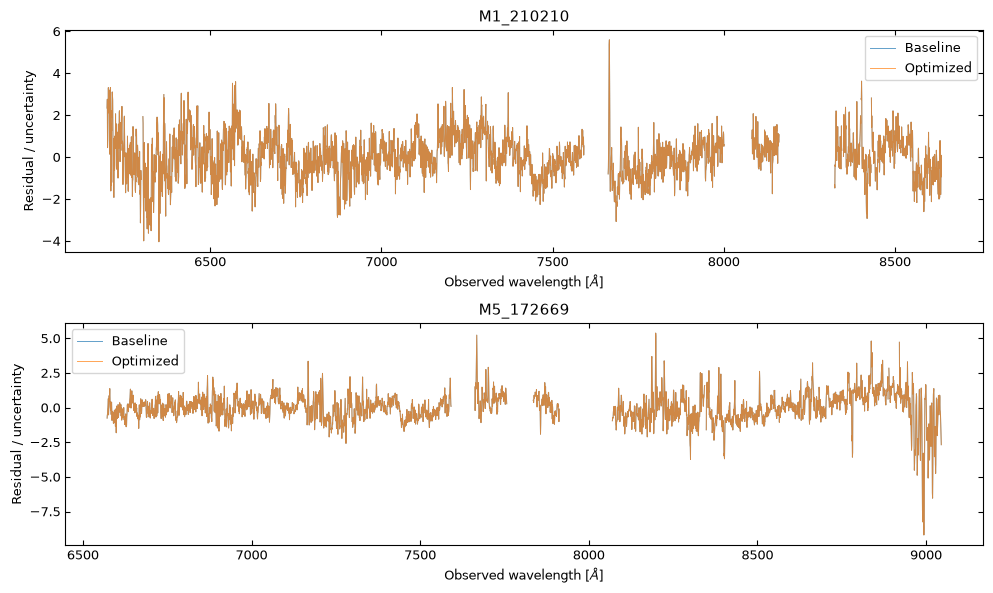

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
for ax, target in zip(axes, TARGETS):
    for variant, label in (("baseline", "Baseline"), ("reduce", "Optimized")):
        folder=RESULT_ROOT/f"{target}-{SEEDS[0]}-{variant}"
        with h5py.File(folder/"ceridwen_derived_outputs.h5") as f:
            g=f["spectrum"]
            mask=g["mask"][()].astype(bool)
            wave=g["wavelength"][()]
            pull=(g["observed"][()]-g["posterior_q50"][()])/g["effective_uncertainty"][()]
            ax.plot(wave,np.where(mask,pull,np.nan),lw=.7,alpha=.7,label=label)
    ax.set(title=target,xlabel=r"Observed wavelength [$\AA$]",ylabel="Residual / uncertainty")
    ax.legend()
fig.tight_layout()
plt.show()


- Preserve nested-sampling weights in the joint posterior comparison.

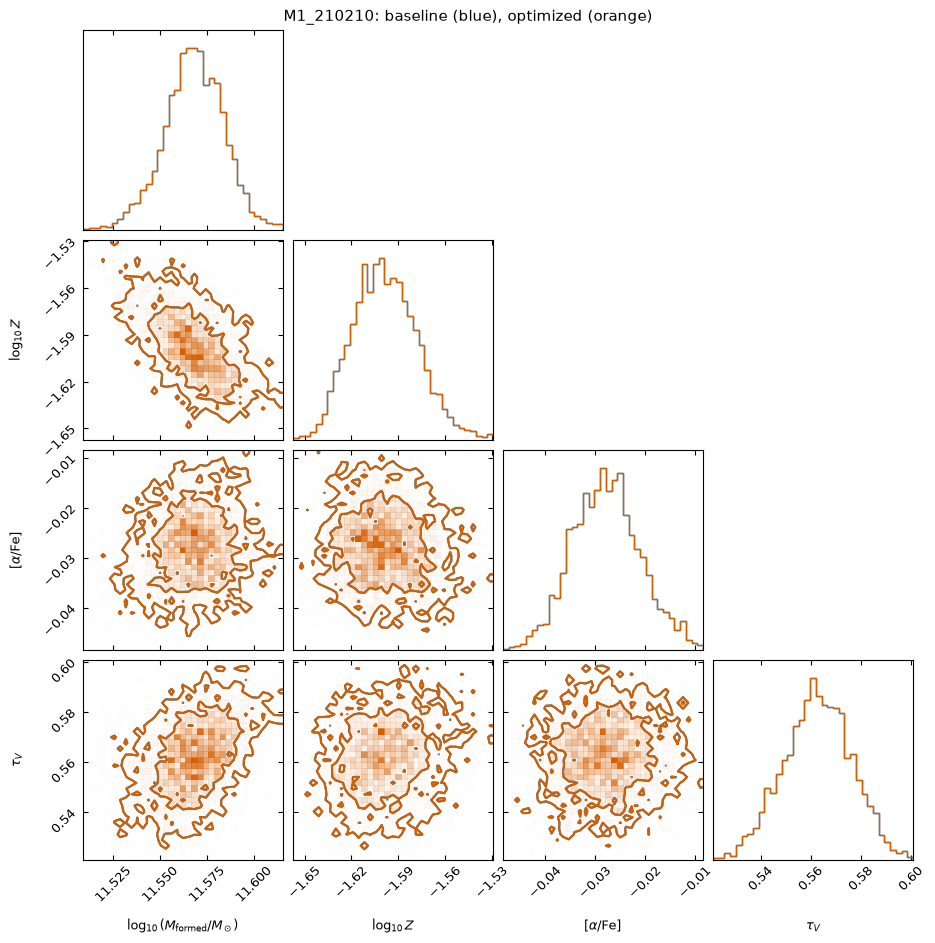

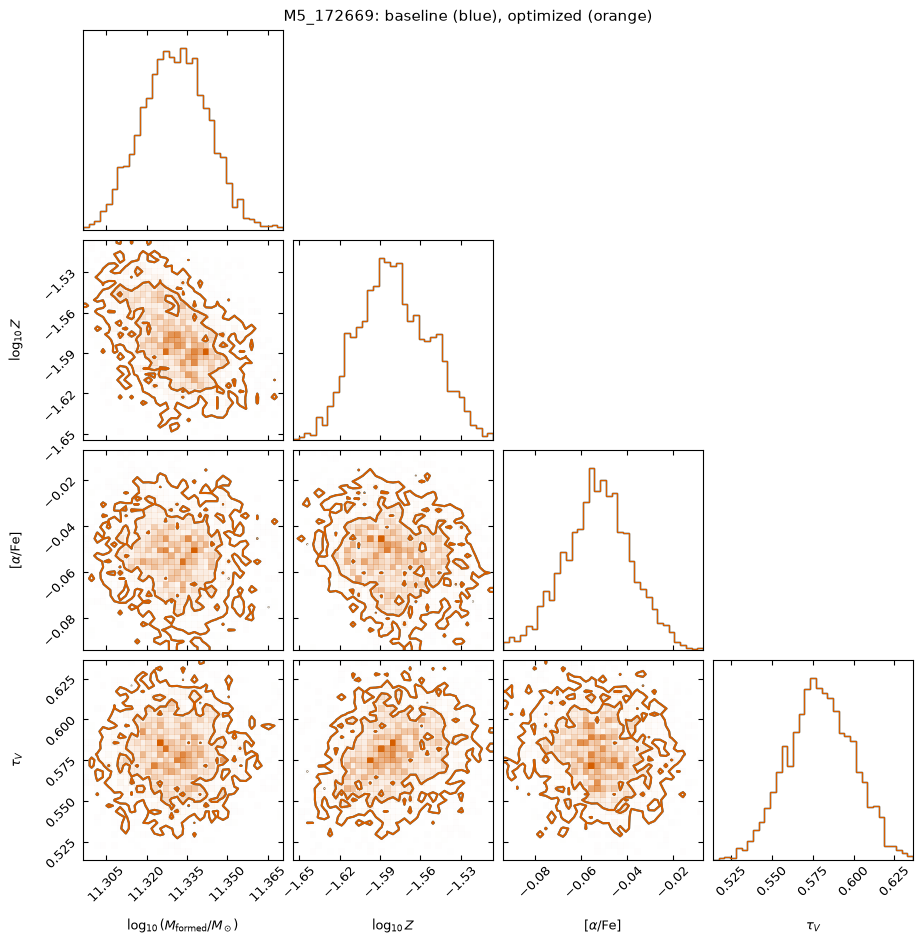

In [6]:
names=["logmass", "Z", "afe", "diffuse_tau_kc"]
labels=[r"$\log_{10}(M_\mathrm{formed}/M_\odot)$", r"$\log_{10} Z$", r"$[\alpha/\mathrm{Fe}]$", r"$\tau_V$"]
for target in TARGETS:
    figure=None
    for variant, color in (("baseline", "#0072B2"), ("reduce", "#D55E00")):
        folder=RESULT_ROOT/f"{target}-{SEEDS[0]}-{variant}"
        with h5py.File(folder/"ceridwen_result.h5") as f:
            samples=np.column_stack([f[f"samples/{name}"][()].ravel() for name in names])
            weights=softmax(f["samples/log_weights"][()])
        figure=corner.corner(samples,weights=weights,labels=labels,fig=figure,color=color,
                             bins=35,range=[.997]*4,plot_datapoints=False,levels=(.68,.95))
    figure.suptitle(f"{target}: baseline (blue), optimized (orange)")
    plt.show()


- Keep profiler evidence separate from complete fit timing.

In [7]:
probes={}
for target in TARGETS:
    folder=RESULT_ROOT/f"{target}-{SEEDS[0]}-baseline"
    probes[target]=json.loads((folder/"calibration_replay.json").read_text())
display({target: probe["numerical"] for target,probe in probes.items()})


{'M1_210210': {'prior': {'count': 256,
   'max_abs_delta_loglike': 1.862645149230957e-09,
   'max_relative_gradient_error': 4.384236241660757e-15,
   'max_prediction_difference_in_observed_sigma': {'photometry': 0.0,
    'spectrum': 5.071772646905863e-10}},
  'posterior': {'count': 256,
   'max_abs_delta_loglike': 5.820766091346741e-11,
   'max_relative_gradient_error': 6.58830492785797e-14,
   'max_prediction_difference_in_observed_sigma': {'photometry': 0.0,
    'spectrum': 6.271713977777877e-14}},
  'boundaries': {'count': 26,
   'max_abs_delta_loglike': 5.820766091346741e-11,
   'max_relative_gradient_error': 3.5202701476846293e-16,
   'max_prediction_difference_in_observed_sigma': {'photometry': 0.0,
    'spectrum': 1.3019326254980202e-11}}},
 'M5_172669': {'prior': {'count': 256,
   'max_abs_delta_loglike': 3.725290298461914e-09,
   'max_relative_gradient_error': 3.1298194615008305e-15,
   'max_prediction_difference_in_observed_sigma': {'photometry': 0.0,
    'spectrum': 2.170936

- Separate existing float32 compilation variation from calibration arithmetic.

In [8]:
context=report["compilation_context_check"]
display(pd.DataFrame({batch:{
    "calibration delta lnL, fused":values["value_only_max_abs_delta_loglike"],
    "calibration delta lnL, fixed predictions":values["fixed_predictions_max_abs_delta_loglike"],
    "unchanged baseline delta lnL across contexts, first ten points":values["baseline_compilation_context_first_ten_max_abs_delta_loglike"],
} for batch,values in context.items()}).T)
print(report["compilation_context_note"])
display(pd.DataFrame([{
    "target":p["target"], "seed":p["seed"],
    "saved sample max delta lnL":p["max_abs_paired_loglike_difference"],
    "delta log evidence":p["evidence"]["delta"],
    "max posterior median shift / 68% half-width":max(v["median_shift_over_68pct_half_width"] for v in p["derived"].values()),
} for p in report["pairs"]]))

,"calibration delta lnL, fused","calibration delta lnL, fixed predictions","unchanged baseline delta lnL across contexts, first ten points"
100,3.725290e-09,3.725290e-09,0.00000
500,9.313226e-10,1.862645e-09,7701.11515


The unchanged float32 forward model gives different likelihood values across batch sizes and fused versus separately compiled predictions. The 7701.115 difference in the extreme-prior saved fit values is reproduced by the baseline alone. Within each tested compilation path, baseline and candidate agree to less than 4e-9. Full-fit posterior and evidence comparisons are recorded separately.


,target,seed,saved sample max delta lnL,delta log evidence,max posterior median shift / 68% half-width
0,M1_210210,20260906,3.725290e-09,0.000000e+00,2.420490e-14
1,M1_210210,20260907,7.701115e+03,-2.328306e-10,1.273632e-11
2,M5_172669,20260906,2.142042e-08,0.000000e+00,1.250984e-12
3,M5_172669,20260907,3.725290e-09,0.000000e+00,1.095563e-13
